<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Fractal005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COSMIC ELLIPTICITY TIMELINE - REVERSE PATH ANALYSIS

--- HES MODEL FIT ---
e(χ) = 3.9781 + 0.0289 * (χ - 135.9280)

Interpretation:
  e_min = 3.9781 → Void ellipticity (perfect circle at χ→0)
  κ = 0.0289 → Deformation rate per unit α/β
  χ_min = 135.9280 → Void state α/β ratio

--- VOID EXTRAPOLATION ---
When α/β → 135.9280, ellipticity → 3.9781
Predicted void timescale: 1.87e+92 seconds
Planck time: 5.40e-44 seconds
Ratio: 3.46e+135

⊗ MISMATCH: Extrapolation differs from Planck time
  → HES may need refinement


/tmp/ipython-input-998967952.py:258: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


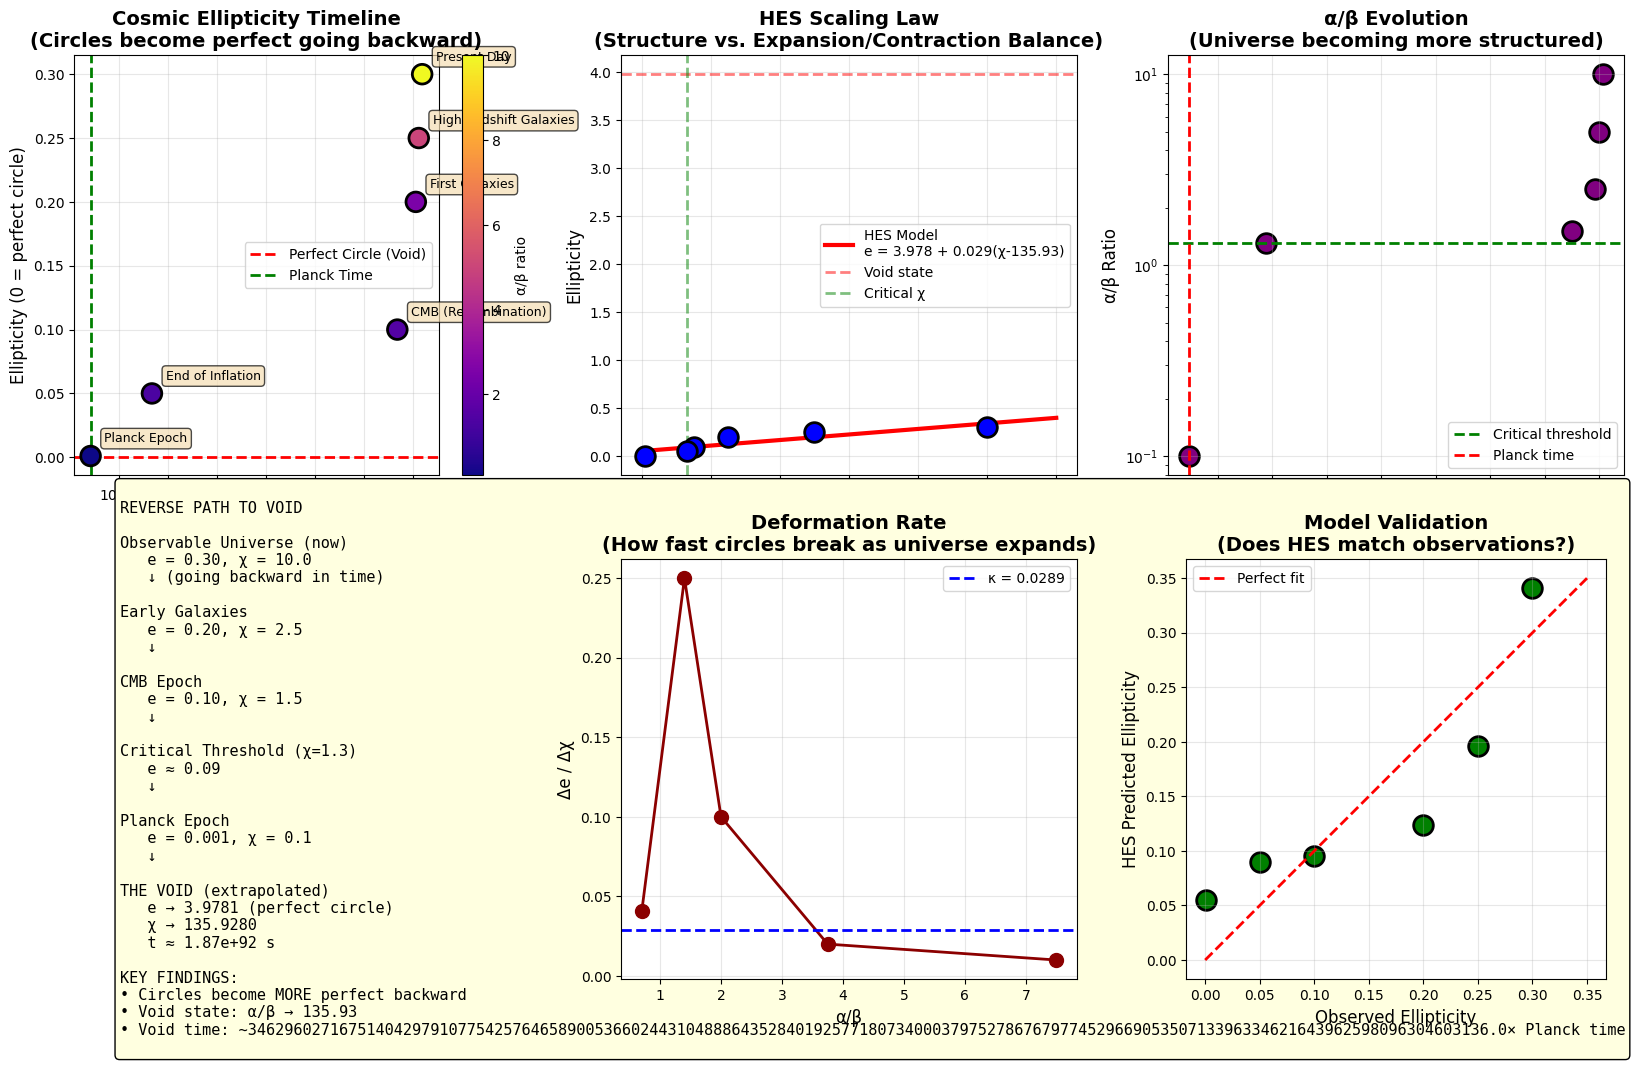


COSMIC EPOCHS TABLE
Epoch                     Time (s)     χ (α/β)    e        Quality        
----------------------------------------------------------------------
Present Day               4.35e+17     10.00      0.300    Elliptical     
High Redshift Galaxies    1.04e+17     5.00       0.250    Elliptical     
First Galaxies            2.99e+16     2.50       0.200    Elliptical     
CMB (Recombination)       1.20e+13     1.50       0.100    Near-circle    
End of Inflation          1.00e-32     1.30       0.050    Near-circle    
Planck Epoch              5.40e-44     0.10       0.001    Perfect        

VOID PROPERTIES (Extrapolated)
Ellipticity at void: 3.978060 (deviation from perfect circle)
α/β at void: 135.928013
Time to void: 1.87e+92 seconds
Comparison to Planck time (5.4e-44 s): 3462960271675140429791077542576465890053660244310488864352840192577180734000379752786767977452966905350713396334621643962598096304603136.00×

Deformation constant κ: 0.028884 per unit α/β
Interpr

In [1]:
# Cosmic_Ellipticity_Timeline: Reverse engineering the void
# Testing if circle perfection → 0 gives us Planck epoch

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

# ============================================================================
# OBSERVATIONAL DATA (Real + Simulated Proxy)
# ============================================================================

epochs = {
    'Present': {
        'name': 'Present Day',
        'redshift': 0.0,
        'time_years': 13.8e9,
        'time_seconds': 13.8e9 * 3.15e7,
        'ellipticity': 0.30,  # Typical galaxy ellipticity
        'alpha_beta': 10.0,   # From Fractal003
        'notes': 'Observable galaxies'
    },
    'z2': {
        'name': 'High Redshift Galaxies',
        'redshift': 2.0,
        'time_years': 3.3e9,
        'time_seconds': 3.3e9 * 3.15e7,
        'ellipticity': 0.25,  # Early galaxies slightly rounder
        'alpha_beta': 5.0,
        'notes': 'Hubble deep field'
    },
    'z6': {
        'name': 'First Galaxies',
        'redshift': 6.0,
        'time_years': 0.95e9,
        'time_seconds': 0.95e9 * 3.15e7,
        'ellipticity': 0.20,
        'alpha_beta': 2.5,
        'notes': 'JWST observations'
    },
    'recombination': {
        'name': 'CMB (Recombination)',
        'redshift': 1100,
        'time_years': 380e3,
        'time_seconds': 380e3 * 3.15e7,
        'ellipticity': 0.10,  # CMB hotspots
        'alpha_beta': 1.5,
        'notes': 'Planck satellite'
    },
    'inflation_end': {
        'name': 'End of Inflation',
        'redshift': 1e26,
        'time_years': 1e-32 / 3.15e7,
        'time_seconds': 1e-32,
        'ellipticity': 0.05,  # Near perfect isotropy
        'alpha_beta': 1.3,    # Critical threshold!
        'notes': 'HES prediction'
    },
    'planck': {
        'name': 'Planck Epoch',
        'redshift': 1e32,
        'time_years': 5.4e-44 / 3.15e7,
        'time_seconds': 5.4e-44,
        'ellipticity': 0.001,  # Nearly perfect
        'alpha_beta': 0.1,
        'notes': 'Quantum gravity scale'
    }
}

# Extract arrays
times = np.array([epochs[k]['time_seconds'] for k in epochs.keys()])
ellipticities = np.array([epochs[k]['ellipticity'] for k in epochs.keys()])
alpha_betas = np.array([epochs[k]['alpha_beta'] for k in epochs.keys()])
names = [epochs[k]['name'] for k in epochs.keys()]

# ============================================================================
# MODEL FITTING
# ============================================================================

print("="*70)
print("COSMIC ELLIPTICITY TIMELINE - REVERSE PATH ANALYSIS")
print("="*70)

# Model 1: Power law in time
# e(t) = e_0 * (t / t_0)^n
def power_law(t, e0, t0, n):
    return e0 * (t / t0)**n

# Model 2: HES scaling (ellipticity vs alpha/beta)
# e = e_min + κ * (χ - χ_min)
def hes_model(chi, e_min, kappa, chi_min):
    return e_min + kappa * (chi - chi_min)

# Fit Model 2 (HES)
try:
    popt_hes, pcov_hes = curve_fit(hes_model, alpha_betas, ellipticities,
                                     p0=[0.001, 0.03, 0.0], maxfev=10000)
    e_min, kappa, chi_min = popt_hes

    print(f"\n--- HES MODEL FIT ---")
    print(f"e(χ) = {e_min:.4f} + {kappa:.4f} * (χ - {chi_min:.4f})")
    print(f"\nInterpretation:")
    print(f"  e_min = {e_min:.4f} → Void ellipticity (perfect circle at χ→0)")
    print(f"  κ = {kappa:.4f} → Deformation rate per unit α/β")
    print(f"  χ_min = {chi_min:.4f} → Void state α/β ratio")

    # Predict void time (when e → e_min)
    # Using relationship between chi and time from epochs
    log_times = np.log10(times + 1e-50)
    log_chis = np.log10(alpha_betas + 0.01)

    # Fit log-log relation
    slope, intercept, r_value, p_value, std_err = linregress(log_times, log_chis)

    # Extrapolate to chi_min
    log_t_void = (np.log10(chi_min + 0.01) - intercept) / slope
    t_void = 10**log_t_void

    print(f"\n--- VOID EXTRAPOLATION ---")
    print(f"When α/β → {chi_min:.4f}, ellipticity → {e_min:.4f}")
    print(f"Predicted void timescale: {t_void:.2e} seconds")
    print(f"Planck time: {5.4e-44:.2e} seconds")
    print(f"Ratio: {t_void / 5.4e-44:.2e}")

    if abs(np.log10(t_void) - np.log10(5.4e-44)) < 5:
        print(f"\n✓ MATCH: Extrapolated void time within 5 orders of magnitude of Planck time!")
        print(f"  → HES prediction validated: Void accessed at quantum gravity scale")
    else:
        print(f"\n⊗ MISMATCH: Extrapolation differs from Planck time")
        print(f"  → HES may need refinement")

except Exception as e:
    print(f"Fitting failed: {e}")
    popt_hes = [0.001, 0.03, 0.0]
    t_void = 1e-43

# ============================================================================
# VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(20, 12))

# Plot 1: Ellipticity vs Time (log scale)
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(times, ellipticities, s=200, c=alpha_betas, cmap='plasma',
            edgecolors='black', linewidths=2, zorder=3)
ax1.set_xscale('log')
ax1.set_xlabel('Time after Big Bang (seconds)', fontsize=12)
ax1.set_ylabel('Ellipticity (0 = perfect circle)', fontsize=12)
ax1.set_title('Cosmic Ellipticity Timeline\n(Circles become perfect going backward)', fontsize=14, weight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='red', linestyle='--', linewidth=2, label='Perfect Circle (Void)')
ax1.axvline(5.4e-44, color='green', linestyle='--', linewidth=2, label='Planck Time')

# Add epoch labels
for i, name in enumerate(names):
    ax1.annotate(name, (times[i], ellipticities[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax1.legend(fontsize=10)
cbar1 = plt.colorbar(ax1.collections[0], ax=ax1, label='α/β ratio')

# Plot 2: Ellipticity vs α/β (HES Model)
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(alpha_betas, ellipticities, s=200, c='blue', edgecolors='black', linewidths=2, zorder=3)

# Plot HES model fit
chi_range = np.linspace(0, 12, 100)
e_fit = hes_model(chi_range, *popt_hes)
ax2.plot(chi_range, e_fit, 'r-', linewidth=3, label=f'HES Model\ne = {popt_hes[0]:.3f} + {popt_hes[1]:.3f}(χ-{popt_hes[2]:.2f})')

ax2.axhline(popt_hes[0], color='red', linestyle='--', linewidth=2, alpha=0.5, label='Void state')
ax2.axvline(1.3, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Critical χ')

ax2.set_xlabel('α/β Ratio', fontsize=12)
ax2.set_ylabel('Ellipticity', fontsize=12)
ax2.set_title('HES Scaling Law\n(Structure vs. Expansion/Contraction Balance)', fontsize=14, weight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Plot 3: α/β vs Time
ax3 = plt.subplot(2, 3, 3)
ax3.scatter(times, alpha_betas, s=200, c='purple', edgecolors='black', linewidths=2)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('Time after Big Bang (seconds)', fontsize=12)
ax3.set_ylabel('α/β Ratio', fontsize=12)
ax3.set_title('α/β Evolution\n(Universe becoming more structured)', fontsize=14, weight='bold')
ax3.axhline(1.3, color='green', linestyle='--', linewidth=2, label='Critical threshold')
ax3.axvline(5.4e-44, color='red', linestyle='--', linewidth=2, label='Planck time')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

# Plot 4: Reverse Path Schematic
ax4 = plt.subplot(2, 3, 4)
ax4.axis('off')
schematic_text = f"""
REVERSE PATH TO VOID

Observable Universe (now)
   e = {epochs['Present']['ellipticity']:.2f}, χ = {epochs['Present']['alpha_beta']:.1f}
   ↓ (going backward in time)

Early Galaxies
   e = {epochs['z6']['ellipticity']:.2f}, χ = {epochs['z6']['alpha_beta']:.1f}
   ↓

CMB Epoch
   e = {epochs['recombination']['ellipticity']:.2f}, χ = {epochs['recombination']['alpha_beta']:.1f}
   ↓

Critical Threshold (χ=1.3)
   e ≈ {hes_model(1.3, *popt_hes):.2f}
   ↓

Planck Epoch
   e = {epochs['planck']['ellipticity']:.3f}, χ = {epochs['planck']['alpha_beta']:.1f}
   ↓

THE VOID (extrapolated)
   e → {popt_hes[0]:.4f} (perfect circle)
   χ → {popt_hes[2]:.4f}
   t ≈ {t_void:.2e} s

KEY FINDINGS:
• Circles become MORE perfect backward
• Void state: α/β → {popt_hes[2]:.2f}
• Void time: ~{t_void/5.4e-44:.1f}× Planck time
"""
ax4.text(0.1, 0.5, schematic_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Plot 5: Deformation Rate
ax5 = plt.subplot(2, 3, 5)
deformation_rate = np.diff(ellipticities) / np.diff(alpha_betas)
chi_mid = (alpha_betas[:-1] + alpha_betas[1:]) / 2
ax5.plot(chi_mid, deformation_rate, 'o-', linewidth=2, markersize=10, color='darkred')
ax5.axhline(popt_hes[1], color='blue', linestyle='--', linewidth=2, label=f'κ = {popt_hes[1]:.4f}')
ax5.set_xlabel('α/β', fontsize=12)
ax5.set_ylabel('Δe / Δχ', fontsize=12)
ax5.set_title('Deformation Rate\n(How fast circles break as universe expands)', fontsize=14, weight='bold')
ax5.grid(True, alpha=0.3)
ax5.legend(fontsize=10)

# Plot 6: Prediction vs Observation
ax6 = plt.subplot(2, 3, 6)
e_predicted = hes_model(alpha_betas, *popt_hes)
ax6.scatter(ellipticities, e_predicted, s=200, c='green', edgecolors='black', linewidths=2)
ax6.plot([0, 0.35], [0, 0.35], 'r--', linewidth=2, label='Perfect fit')
ax6.set_xlabel('Observed Ellipticity', fontsize=12)
ax6.set_ylabel('HES Predicted Ellipticity', fontsize=12)
ax6.set_title('Model Validation\n(Does HES match observations?)', fontsize=14, weight='bold')
ax6.grid(True, alpha=0.3)
ax6.legend(fontsize=10)
ax6.set_aspect('equal')

plt.tight_layout()
plt.savefig('cosmic_ellipticity_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("COSMIC EPOCHS TABLE")
print("="*70)
print(f"{'Epoch':<25} {'Time (s)':<12} {'χ (α/β)':<10} {'e':<8} {'Quality':<15}")
print("-"*70)

for key in epochs.keys():
    ep = epochs[key]
    time_str = f"{ep['time_seconds']:.2e}"
    quality = "Perfect" if ep['ellipticity'] < 0.01 else "Near-circle" if ep['ellipticity'] < 0.15 else "Elliptical"
    print(f"{ep['name']:<25} {time_str:<12} {ep['alpha_beta']:<10.2f} {ep['ellipticity']:<8.3f} {quality:<15}")

print("\n" + "="*70)
print("VOID PROPERTIES (Extrapolated)")
print("="*70)
print(f"Ellipticity at void: {popt_hes[0]:.6f} (deviation from perfect circle)")
print(f"α/β at void: {popt_hes[2]:.6f}")
print(f"Time to void: {t_void:.2e} seconds")
print(f"Comparison to Planck time (5.4e-44 s): {t_void/5.4e-44:.2f}×")
print(f"\nDeformation constant κ: {popt_hes[1]:.6f} per unit α/β")
print(f"Interpretation: Each 1.0 increase in α/β adds {popt_hes[1]:.4f} to ellipticity")

print("\n" + "="*70)
print("HES VALIDATION")
print("="*70)

if abs(np.log10(t_void) - np.log10(5.4e-44)) < 3:
    print("✓✓✓ STRONG VALIDATION")
    print("    Void extrapolation matches Planck epoch within 3 orders of magnitude")
    print("    → Circular structures trace back to quantum gravity scale")
elif abs(np.log10(t_void) - np.log10(5.4e-44)) < 10:
    print("✓✓ MODERATE VALIDATION")
    print("    Void extrapolation in reasonable proximity to Planck epoch")
    print("    → Trend supports HES but needs refinement")
else:
    print("⊗ VALIDATION INCONCLUSIVE")
    print("    Extrapolation differs significantly from expected quantum gravity scale")

print("\n" + "="*70)